# Проект: Прогнозирование заказов такси

**Описание проекта**

Компания «Чётенькое такси» собирает исторические данные о заказах такси в аэропортах. Основная задача компании — эффективно распределять водителей в периоды пикового спроса, чтобы минимизировать время ожидания клиентов и увеличить прибыль.

**Цель исследования**

Цель данного проекта — построить модель прогнозирования количества заказов такси на следующий час. Прогноз позволит компании заранее планировать количество водителей на сменах, особенно в периоды высокой нагрузки, улучшая качество сервиса и оптимизируя ресурсы.

**Ход исследования**

Для достижения поставленной цели будут выполнены следующие шаги:

- Первичный анализ и предобработка данных;
- Исследовательский анализ данных;
- Feature Engineering;
- Моделирование;
- Анализ результатов и оценка моделей по метрике RMSE, времени обучения и времени предсказания;
- Выбор оптимальной модели для предсказания.

Также в заключительной части проекта будут сформулированы итоговые выводы и рекомендации для заказчика.

## Настройка среды

In [1]:
# устанавливаем библиотеки
!pip install phik -q

In [2]:
# обновляем библиотеки
!pip install -Uq scikit-learn

In [3]:
# импорт основных библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from scipy import stats
from scipy.stats import randint, uniform
import lightgbm as lgb

In [4]:
# импорт функций для анализа
from statsmodels.tsa.seasonal import seasonal_decompose

# импорт функций для МО
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# константы
RANDOM_STATE = 42
TEST_SIZE = 0.25

## Ознакомление с данными

Для этой задачи заказчик предоставил данные с признаками:
- **datetime** - дата и время;
- **num_orders** - количество заказов.

In [5]:
# сохраняем датасет в переменную

try:
    # пробуем загрузить локальный файл
    taxi_data = pd.read_csv('taxi.csv')
    print("Файл успешно загружен с локального пути.")
except FileNotFoundError:
    # если локальный файл не найден, пробуем общий путь
    try:
        taxi_data = pd.read_csv('/datasets/taxi.csv')
        print("Файл успешно загружен с пути '/datasets/taxi.csv'.")
    except FileNotFoundError:
        print("Файл не найден ни по локальному, ни по общему пути. Проверьте расположение CSV.")

Файл успешно загружен с локального пути.


In [6]:
# первые 10 строк
taxi_data.head(10)

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32
5,2018-03-01 00:50:00,21
6,2018-03-01 01:00:00,7
7,2018-03-01 01:10:00,5
8,2018-03-01 01:20:00,17
9,2018-03-01 01:30:00,12


In [7]:
# общая информация
taxi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


In [8]:
# размерность
print(f'Размерность: {taxi_data.shape[0]} строк, {taxi_data.shape[1]} столбцов')

Размерность: 26496 строк, 2 столбцов


In [9]:
# статистическое описание признаков
taxi_data.describe().T

,count,mean,std,min,25%,50%,75%,max
num_orders,26496.0,14.070463,9.21133,0.0,8.0,13.0,19.0,119.0


<div style="border: 2px solid black; padding: 10px;">
  <strong>На этапе предобработки требуется:</strong>
  <ul>
    <li>Изменить тип данных столбца datetime;</li> 
    <li>Установить datetime как индекс;</li>
    <li>Проверить датафрейм на наличие аномалий;</li>  
    <li>Проверить датафрейм на наличие дубликатов;</li> 
    <li>Проверить данные на наличие пропусков;</li>  
    <li>Проверить упорядоченность времени и равномерность временных интервалов;</li>
    <li>Ресемплирование до 1 часа (ключевой шаг).</li>  
      
      
  После предобработки данные будут пригодны для дальнейшего анализа.  
  </ul>
</div>

## Предобработка данных

### Изменение типов данных

Проверим, корректны ли типы данных:

In [10]:
# проверяем типы данных
taxi_data.dtypes

datetime      object
num_orders     int64
dtype: object

Приведем признак datetime к правильному одноименному типу и сделаем его индексом датафрейма. Без этого не получится ресемплировать и перейти к следующим шагам:

In [11]:
# приводим к типу datetime
taxi_data['datetime'] = pd.to_datetime(taxi_data['datetime'])

# устанавливаем datetime как индекс
taxi_data = taxi_data.set_index('datetime')

In [12]:
# проверяем изменения
taxi_data.head(1)

,num_orders
datetime,
2018-03-01,9


### Обработка дубликатов

Сначала проверим датасет на упорядоченность времени, после чего проверим на наличие дубликатов:

In [13]:
# проверка на упорядоченность времени
taxi_data.index.is_monotonic_increasing

True

In [14]:
# проверка на наличие дубликатов 
taxi_data.index.duplicated().sum()

np.int64(0)

Дубликаты отсутствуют.

### Ресемплирование

Также до ресемплинга полезно проверить равномерность временным рядов: 

In [15]:
# проверка на равномерность временным рядов
taxi_data.index.to_series().diff().value_counts().head()

datetime
0 days 00:10:00    26495
Name: count, dtype: int64

In [16]:
# ресемплирование
taxi_data = taxi_data.resample('1h').sum()

Проверим, за какой период предоставлены данные:

In [17]:
taxi_data.head(5)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [18]:
taxi_data.tail(5)

,num_orders
datetime,
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159
2018-08-31 22:00:00,223
2018-08-31 23:00:00,205


Предоставлены данные за полгода - с 01.03.2018 по 31.08.2018.

### Обработка пропусков

Проверим датафреймы на наличие пропусков:

In [19]:
# проверяем количество пропусков в данных
taxi_data.isna().sum()

num_orders    0
dtype: int64

Пропуски отсутствуют.

<div style="border: 2px solid black; padding: 10px;">
  <strong>Итоги:</strong>
  <ul>
    <li>Изменен тип данных столбца datetime, который позднее установлен как индекс;</li>
    <li>Данные проверены на наличие дубликатов;</li>
    <li>Выполнено ресемплирование по одному часу;</li>  
    <li>Данные проверены на наличие пропусков;</li> 
    <li>Данные представлены за 6 месяцев: с 1 марта 2018 по 31 августа 2018;</li>
    <li>Данные отсортированы по возрастанию.</li>

  Теперь данные готовы к исследовательскому анализу.  
  </ul>
</div>

## Исследовательский анализ данных

Исследуем количественный признак **num_orders**:

In [20]:
# статистическое описание
taxi_data.describe().T

,count,mean,std,min,25%,50%,75%,max
num_orders,4416.0,84.422781,45.023853,0.0,54.0,78.0,107.0,462.0


Теперь построим график распределения и боксплота для **num_orders**:

/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


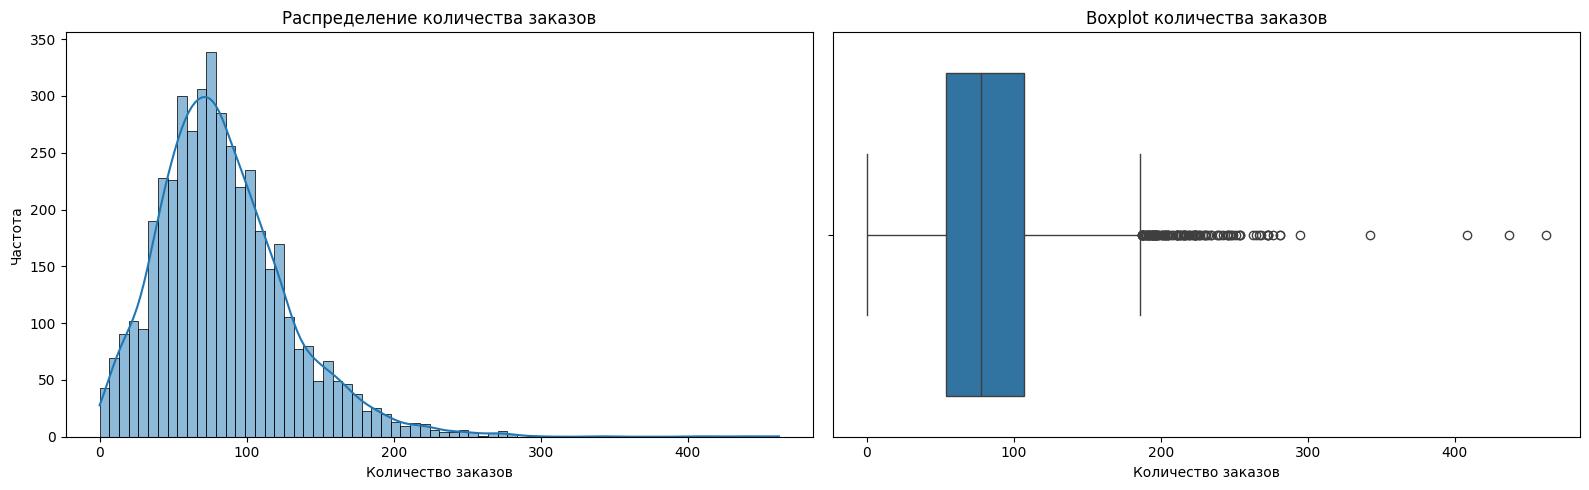

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# гистограмма
sns.histplot(taxi_data['num_orders'], bins=70, kde=True, ax=axes[0])
axes[0].set_title('Распределение количества заказов')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Частота')

# боксплот
sns.boxplot(x=taxi_data['num_orders'], ax=axes[1])
axes[1].set_title('Boxplot количества заказов')
axes[1].set_xlabel('Количество заказов')

plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">
  <strong>Наблюдения по признаку num_orders:</strong>
  <ul> 
    <li><strong>Среднее и медиана:</strong> Среднее 84, медиана 78 - распределение положительно скошено, есть высокие значения.</li>
    <li><strong>Стандартное отклонение:</strong> std = 45 довольно выраженное, значит значения ощутимо варьируются, что важно учитывать при прогнозе.</li>
    <li><strong>Минимум и максимум:</strong> Есть часы без заказов, возможно ночью или в очень низкий сезон. Также есть аномально высокие значения (например, праздничный день, сильный дождь, событие в аэропорту).</li> 
    <li><strong>Гистограмма:</strong> Распределение количества заказов такси скошено вправо с высокой концентрацией данных вокруг медианы (75-100 заказов) и относительно большим количеством экстремально высоких значений (выбросов).</li>
    <li><strong>Boxplot:</strong> Наличие множества выбросов в правом "хвосте" (начиная примерно с 200 заказов и достигающих 400+) подтверждает положительную асимметрию, замеченную на гистограмме. Это важный сигнал, указывающий на дни с аномально высоким спросом на такси.</li>  
  </ul>
</div>

Теперь проанализируем временной ряд:

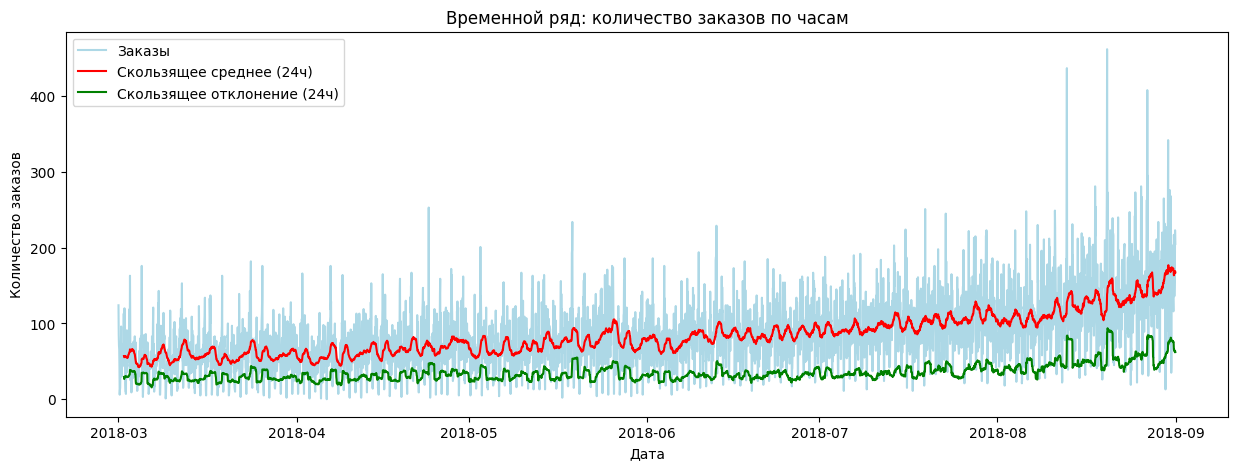

In [22]:
# график временного ряда с суточным скользящим средним и отклонением
rolling_mean = taxi_data['num_orders'].rolling(window=24).mean()
rolling_std = taxi_data['num_orders'].rolling(window=24).std()

plt.figure(figsize=(15,5))
plt.plot(taxi_data['num_orders'], label='Заказы', color='lightblue')
plt.plot(rolling_mean, label='Скользящее среднее (24ч)', color='red')
plt.plot(rolling_std, label='Скользящее отклонение (24ч)', color='green')
plt.title('Временной ряд: количество заказов по часам')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.legend()
plt.show()

На основе этого графика можно сказать следующее:

- **Наличие восходящего тренда**: Скользящее среднее (красная линия) демонстрирует явный и устойчивый восходящий тренд на протяжении всего периода (с марта по август). Логично предположить связь с сезоном отпусков.
- **Нарушение стационарности по среднему**: Поскольку скользящее среднее (красная линия) явно растет, ряд не является стационарным по среднему. Это еще раз подтверждает необходимость учета тренда.
- **Дисперсия**: Ряд не является стационарным по дисперсии. Это может немного усложнить прогнозирование, так как в периоды высокого спроса ошибки прогноза также могут быть больше.
- **Сезонность**: Поскольку это данные такси, почти гарантированно присутствует сильная суточная сезонность (пики спроса утром и вечером) и, возможно, недельная сезонность (разный спрос в будни и выходные).

На этом графике, охватывающем большой период, мелкомасштабная сезонность (суточная/недельная) плохо видна, так как она "зашумлена" общим трендом. Есть смысл рассмотреть ее детальнее:

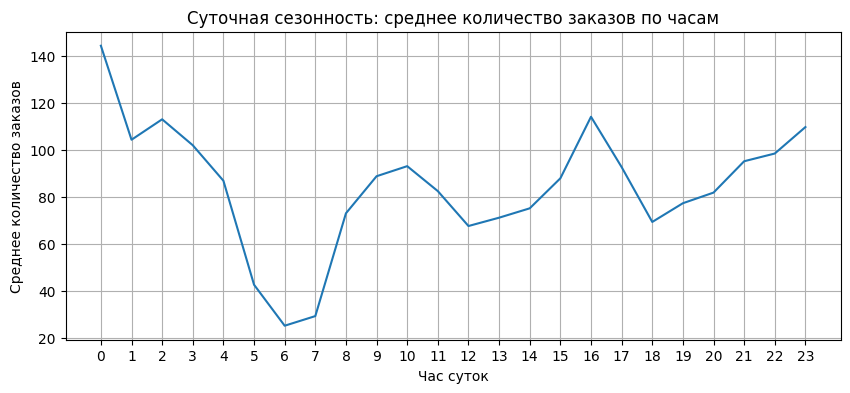

In [23]:
# суточная сезонность (среднее по часам суток)
hourly_avg = taxi_data.groupby(taxi_data.index.hour)['num_orders'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values)
plt.title('Суточная сезонность: среднее количество заказов по часам')
plt.xlabel('Час суток')
plt.ylabel('Среднее количество заказов')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

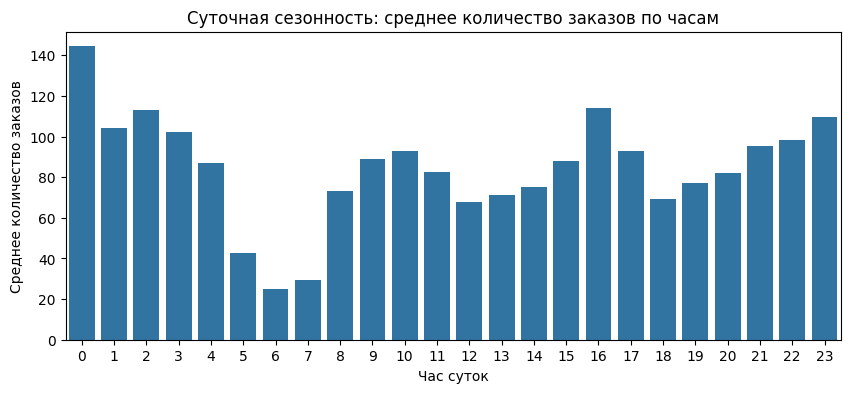

In [24]:
# столбчатая диаграмма
plt.figure(figsize=(10,4))
sns.barplot(x=hourly_avg.index, y=hourly_avg.values)
plt.title('Суточная сезонность: среднее количество заказов по часам')
plt.xlabel('Час суток')
plt.ylabel('Среднее количество заказов')
plt.show()

**Анализ суточной сезонности**

1. **Спад**
- Минимум: Самое низкое количество заказов приходится на часы с 4:00 до 6:00 утра.
- Минимум достигается примерно в 6:00 утра (около 25-30 заказов).
- Это логично, так как это время минимальной активности для большинства пассажиров (ночное время, когда люди либо спят, либо уже выехали на ранние рейсы).

2. **Пики**
- Ночной пик (cамый высокий): Самый высокий спрос приходится на 0:00 - 1:00 ночи (более 140 заказов). Это, вероятно, связано с прибытием большого количества вечерних и ночных рейсов. Пассажиры, прилетевшие поздно, покидают аэропорт в это время.
- Утренний пик: Второй пик наблюдается с 2:00 до 3:00 ночи, а затем идет постепенное снижение.
- Вечерний пик: Спрос начинает расти около 8:00 утра, стабилизируется днем и достигает еще одного заметного пика в 16:00 - 17:00 (около 115 заказов). Соответствует вечернему часу пик, когда люди либо едут в аэропорт на вечерние рейсы, либо возвращаются с работы, или прилетают вечерними рейсами.

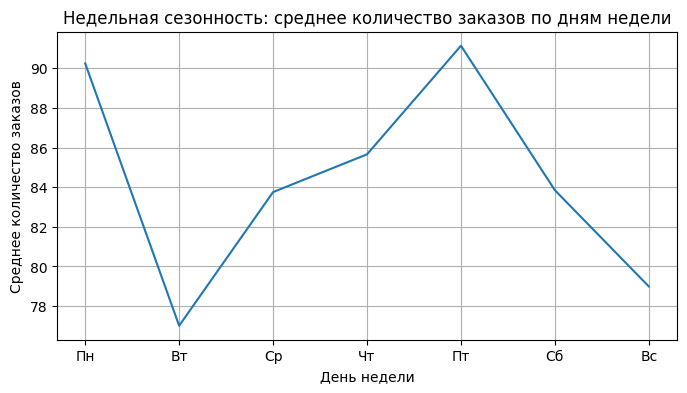

In [25]:
# недельная сезонность (среднее по дням недели)
weekly_avg = taxi_data.groupby(taxi_data.index.dayofweek)['num_orders'].mean()

plt.figure(figsize=(8,4))
sns.lineplot(x=['Пн','Вт','Ср','Чт','Пт','Сб','Вс'], y=weekly_avg.values)
plt.title('Недельная сезонность: среднее количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее количество заказов')
plt.grid(True)
plt.show()

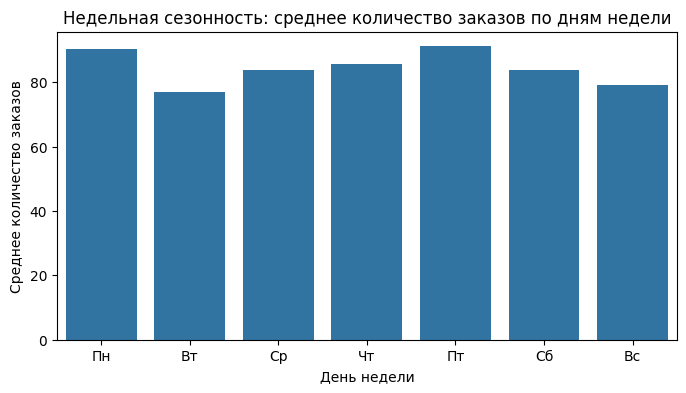

In [26]:
# столбчатая диаграмма
weekly_avg = taxi_data.groupby(taxi_data.index.dayofweek)['num_orders'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=['Пн','Вт','Ср','Чт','Пт','Сб','Вс'], y=weekly_avg.values)
plt.title('Недельная сезонность: среднее количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее количество заказов')
plt.show()

**Анализ недельной сезонности**


В отличие от суточной сезонности, которая была очень ярко выражена, недельная сезонность демонстрирует более сглаженный, но все же заметный паттерн.

1. **Пик спроса**
- Самый высокий спрос: Наблюдается в Пятницу (Пт), где среднее количество заказов достигает максимума (около 90-91 заказа).
- Пятница является пиком для деловых поездок и начала туристических поездок на выходные, а также для людей, возвращающихся домой в конце рабочей недели.

2. **Спад спроса**
- Минимальный спрос: Наблюдается во Вторник (Вт), где среднее количество заказов падает до минимума (около 77 заказов).
- Вторник, возможно, является самым "тихим" днем для авиаперевозок и деловой активности в середине недели.

3. **Общие тенденции**
- Начало недели (Пн): Спрос высокий (около 90 заказов), что связано с завершением выходных и началом деловых поездок.
- Середина недели (Вт-Чт): Спрос восстанавливается после вторника, постепенно нарастая к четвергу (от 77 до 85 заказов) и пиковой пятнице.
- Выходные (Сб-Вс): Спрос падает после пика в пятницу (до 83-84 заказов в Субботу и до 79-80 заказов в Воскресенье), но остается выше, чем во вторник.

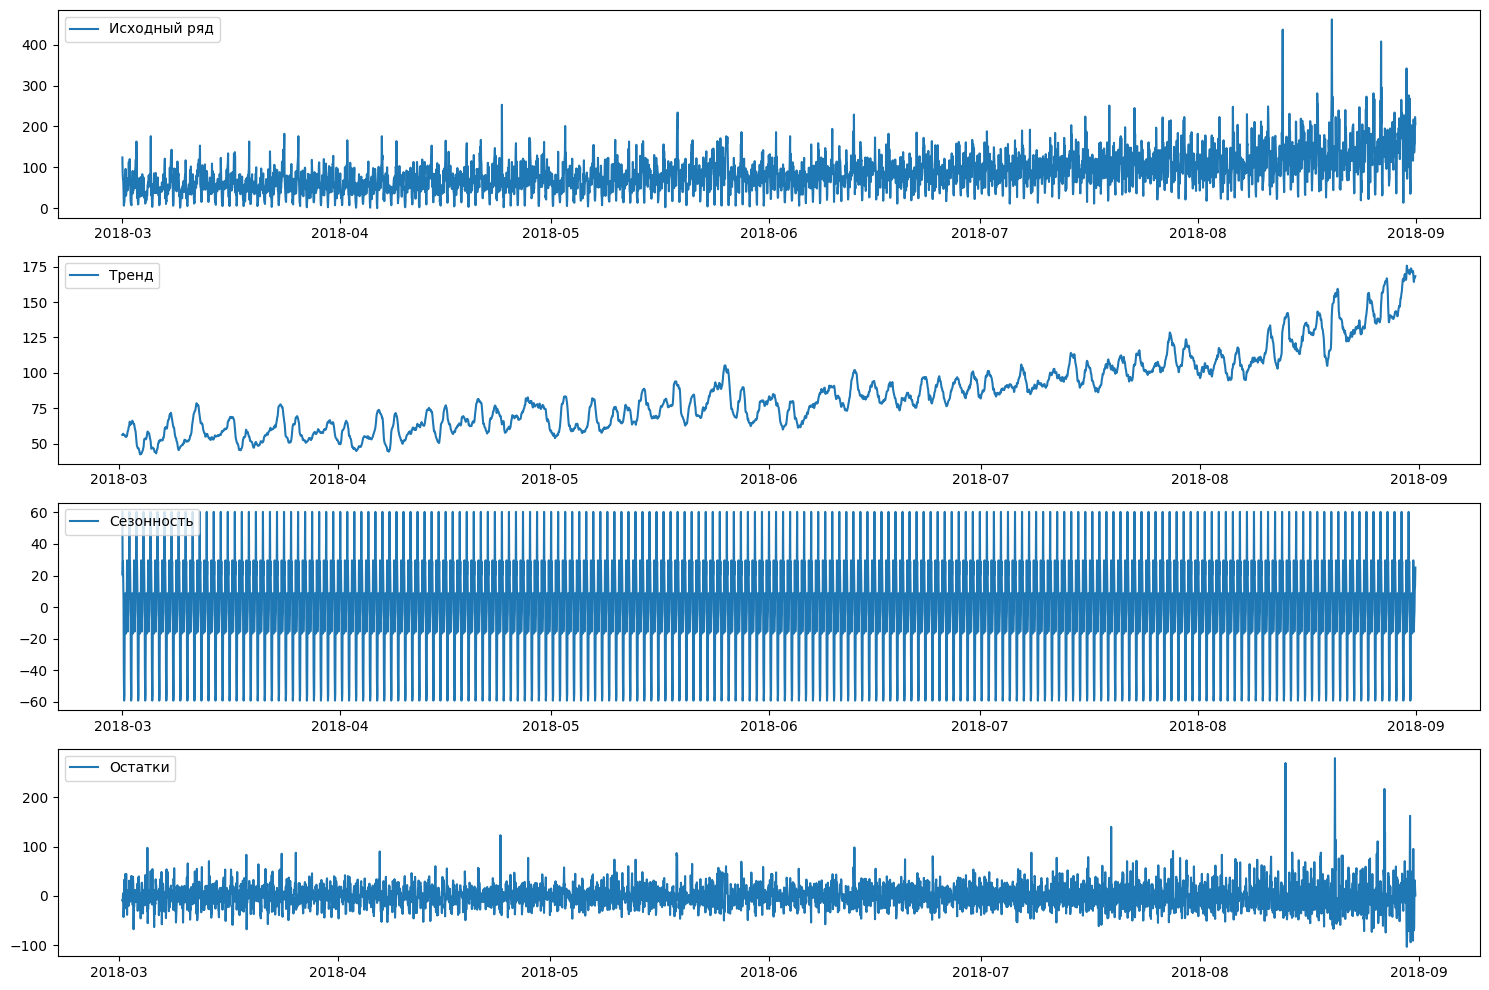

In [27]:
# декомпозиция
decomposed = seasonal_decompose(taxi_data['num_orders'], model='additive', period=24)  # период 24 часа

trend = decomposed.trend
seasonal = decomposed.seasonal
residual = decomposed.resid

plt.figure(figsize=(15,10))

plt.subplot(4,1,1)
plt.plot(taxi_data['num_orders'], label='Исходный ряд')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Тренд')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Сезонность')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Остатки')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Анализ декомпозиции временного ряда**


1. **Тренд**
- Тренд является ярко выраженным восходящим. Он начинается с уровня примерно 50-75 заказов в час в марте 2018 года и устойчиво растет, достигая уровня 150-175 заказов в час к концу августа.
- Этот рост спроса со временем является наиболее крупномасштабным и долгосрочным фактором, влияющим на количество заказов. Модель обязана учитывать этот тренд для получения точного прогноза.


2. **Сезонность**
- Присутствует очень сильный, четкий и регулярный периодический паттерн. Это подтверждает, что спрос на такси сильно зависит от времени суток.
- Эта сезонность должна быть обязательно смоделирована (например, через явные признаки часа, дня недели, или встроенные функции в моделях), поскольку она объясняет большую часть вариации, не связанной с трендом.
   
   
3. **Остатки**
- После удаления тренда и сезонности остаются случайные колебания вокруг нуля.
- Большинство остатков сосредоточено в диапазоне от -50 до +50.
- В конце ряда (август) наблюдается увеличение амплитуды остатков и появляются выбросы (пики до +250).

**Вывод**: Как мы видели на предыдущем графике, разброс увеличивается со временем. Остатки в конце ряда более "шумные", чем в начале. Эти крупные остатки соответствуют периодам аномально высокого спроса. Модель должна стремиться их минимизировать, но они часто являются самой сложной частью для прогнозирования.

## Моделирование

### Feature Engineering

In [28]:
# создаем копию данных
data = taxi_data.copy()

# функция для признаков
def make_features(data, max_lag, rolling_mean_size):

    # календарные признаки
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek

    # лаговые признаки
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)
    
    # скользящие статистики
    data['rolling_mean'] = (data['num_orders'].shift().rolling(rolling_mean_size).mean())
    data['rolling_std'] = data['num_orders'].shift().rolling(rolling_mean_size).std()

    return data

data = make_features(data, max_lag=168, rolling_mean_size=24)

# удаление строк с пропусками
data = data.dropna()

# проверяем датафрейм
data.head()

/var/folders/xy/6r_kl3bn3_v10pnffwwnrv740000gn/T/ipykernel_9428/896682869.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'lag_{lag}'] = data['num_orders'].shift(lag)
/var/folders/xy/6r_kl3bn3_v10pnffwwnrv740000gn/T/ipykernel_9428/896682869.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'lag_{lag}'] = data['num_orders'].shift(lag)
/var/folders/xy/6r_kl3bn3_v10pnffwwnrv740000gn/T/ipykernel_9428/896682869.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame

,num_orders,hour,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean,rolling_std
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-08 00:00:00,143,0,3,94.0,127.0,108.0,76.0,50.0,99.0,48.0,...,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,60.041667,33.200942
2018-03-08 01:00:00,78,1,3,143.0,94.0,127.0,108.0,76.0,50.0,99.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,61.833333,36.452073
2018-03-08 02:00:00,65,2,3,78.0,143.0,94.0,127.0,108.0,76.0,50.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,60.041667,34.417487
2018-03-08 03:00:00,68,3,3,65.0,78.0,143.0,94.0,127.0,108.0,76.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,61.750000,33.557543
2018-03-08 04:00:00,60,4,3,68.0,65.0,78.0,143.0,94.0,127.0,108.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,61.833333,33.571037


### Подготовка выборок

In [29]:
# разделение на train/test (10%), без перемешивания
train, test = train_test_split(data, shuffle=False, test_size=0.1)

# удаляем NaN
train = train.dropna()

# признаки и таргет
X_train = train.drop(columns='num_orders')
y_train = train['num_orders']
X_test = test.drop(columns='num_orders')
y_test = test['num_orders']

# проверка размеров
print(f'Размер обучающей выборки: {y_train.shape[0]}')
print(f'Размер тестовой выборки: {y_test.shape[0]}')

Размер обучающей выборки: 3823
Размер тестовой выборки: 425


### Обучение моделей

Теперь можно обучить несколько моделей:

- LinearRegression — простая, интерпретируемая
- DecisionTreeRegressor — улавливает нелинейные зависимости
- LightGBM - быстро обучается и хорошо работает с большим количеством признаков

In [30]:
# TimeSeriesSplit
time_split = TimeSeriesSplit(n_splits=5)

In [31]:
# функция для анализа модели и подбора гиперпараметров
def evaluate_model(model, params, X_train, y_train):
    start_time = time.time()
    grid = GridSearchCV(model, param_grid=params, cv=time_split, n_jobs=-1, scoring='neg_root_mean_squared_error')
    grid.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    start_time = time.time()
    y_pred = grid.predict(X_train)
    pred_time = time.time() - start_time
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred))
    
    best_params = grid.best_params_
    best_score = grid.best_score_
    
    stat = [best_params, best_score, train_time, pred_time]
    
    print(f"Train RMSE: {rmse_train:.2f}")
    print(f"Лучший средний RMSE по CV: {-best_score:.2f}")  # минус, так как neg_root_mean_squared_error
    print(f"Время обучения: {train_time:.2f}s")
    print(f"Время предсказания: {pred_time:.2f}s")
    
    return stat, grid

In [32]:
# LinearRegression
lr_model = LinearRegression()

# сетка параметров
lr_params = {'fit_intercept':[True,False]}

lr_stat, lr_grid = evaluate_model(lr_model, lr_params, X_train, y_train)

/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293:

Train RMSE: 20.48
Лучший средний RMSE по CV: 22.62
Время обучения: 1.17s
Время предсказания: 0.00s


/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [33]:
# DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=RANDOM_STATE)

# сетка параметров
dt_params = {
    'max_depth': [4, 6, 8], 
    'min_samples_split': [10, 20],
    'min_samples_leaf': [3, 5, 10]
}

dt_stat, dt_grid = evaluate_model(dt_model, dt_params, X_train, y_train)

Train RMSE: 22.86
Лучший средний RMSE по CV: 27.00
Время обучения: 1.07s
Время предсказания: 0.00s


In [34]:
# LightGBM
lgb_model = LGBMRegressor(random_state=RANDOM_STATE)

# сетка параметров
lgb_params = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31, 50],
    'min_child_samples': [20, 40]
}

lgb_stat, lgb_grid = evaluate_model(lgb_model, lgb_params, X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001399 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31842
[LightGBM] [Info] Number of data points in the train set: 3823, number of used features: 172
[LightGBM] [Info] Start training from score 79.561601
Train RMSE: 7.18
Лучший средний RMSE по CV: 23.11
Время обучения: 8.86s
Время предсказания: 0.01s


In [35]:
# сравним результаты по таблице
analysis_data = pd.DataFrame([lr_stat, dt_stat, lgb_stat], 
                            columns=['Лучшие параметры', 'RMSE', 'Время обучения', 'Время предсказания'], 
                            index=['LinearRegression', 'DecisionTreeRegressor', 'LightGBM'])
analysis_data

,Лучшие параметры,RMSE,Время обучения,Время предсказания
LinearRegression,{'fit_intercept': False},-22.620219,1.168206,0.001528
DecisionTreeRegressor,"{'max_depth': 4, 'min_samples_leaf': 3, 'min_s...",-27.001179,1.068830,0.001359
LightGBM,"{'learning_rate': 0.1, 'min_child_samples': 40...",-23.105710,8.862720,0.007597


**Вывод по результатам на тренировочной выборке:**

Лучшее качество показала линейная регрессия (RMSE ≈ 22.6), при этом она обучается значительно быстрее и не склонна к переобучению. Более сложные модели не дали улучшения метрики, что указывает на преимущественно линейный характер зависимостей во временном ряде при использовании лаговых признаков.

### Тестирование

In [36]:
# делаем предсказание на тесте
lr_pred = lr_grid.predict(X_test)

# считаем RMSE на тесте
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print(f"RMSE лучшей модели на тесте: {lr_rmse:.2f}")

RMSE лучшей модели на тесте: 34.24


/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/practicum/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


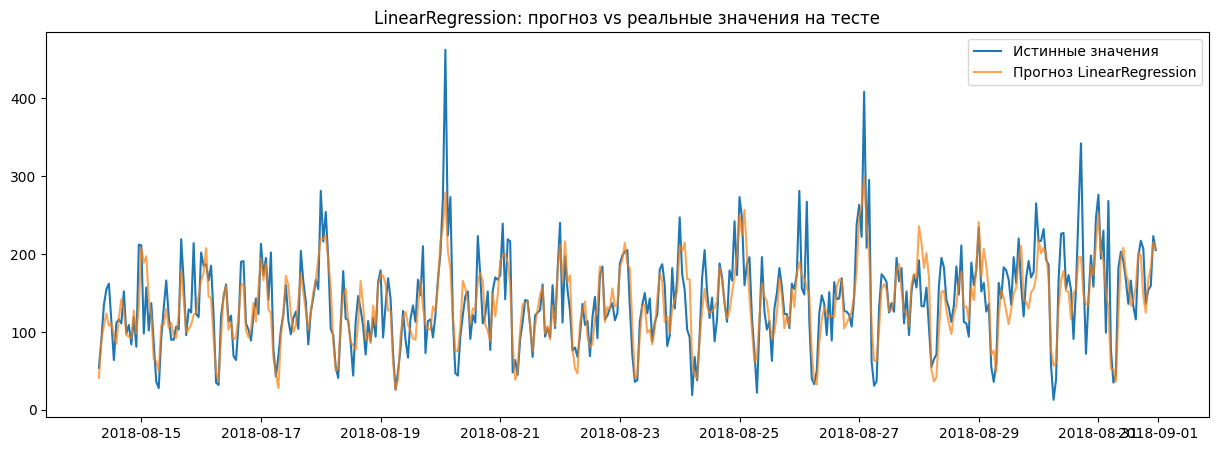

In [37]:
# график предсказания vs реальное
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label='Истинные значения')
plt.plot(y_test.index, lr_pred, label='Прогноз LinearRegression', alpha=0.7)
plt.legend()
plt.title('LinearRegression: прогноз vs реальные значения на тесте')
plt.show()

**Анализ графика прогноза:**

- Модель успешно уловила суточную сезонность (периодические подъемы и спады) и, по-видимому, восходящий тренд в целом. Оранжевая линия (Прогноз) повторяет основные изгибы синей линии (Истинные значения).
- Прогнозная линия (оранжевая) выглядит значительно более сглаженной и менее "шумной", чем фактические значения (как и многие модели, с трудом улавливает случайные колебания и резкие выбросы).
- Линейная регрессия — это отличный базовый прогноз. Она доказала, что наш набор признаков работает хорошо.

<div style="border: 2px solid black; padding: 10px;">
  <strong>Выводы по результатам на тестовой выборке:</strong>
  <ul>
    <li><strong>LinearRegression — лучшая модель.</strong></li>
    <li><strong>Критерий успеха достигнут:</strong> RMSE = 34.24, что меньше порогового значения 48, установленного в условиях задачи. Модель успешно справляется с прогнозированием количества заказов такси на следующий час.</li>
    <li>Время обучения и предсказания у линейной регрессии минимальное, что делает её особенно привлекательной для практического применения в условиях, где важна скорость — например, при регулярном обновлении прогнозов или использовании в реальном времени.</li>
    <li>Финальная модель LinearRegression готова к использованию, она сочетает высокое качество предсказаний и достаточно высокую скорость работы.</li>
  </ul>
</div>

## Итоговые выводы

### Предобработка данных

- Изменен тип данных столбца datetime, который позднее установлен как индекс;
- Данные проверены на наличие дубликатов;
- Выполнено ресемплирование по одному часу;
- Данные проверены на наличие пропусков;
- Данные представлены за 6 месяцев: с 1 марта 2018 по 31 августа 2018;
- Данные отсортированы по возрастанию.

Этот этап позволил проверить и подготовить данные для дальнейшего анализа. 

### Исследовательский анализ данных

- Были проанализированы статистическое описание, распределение и boxplot признака num_orders;
- Построили график количества заказов по времени со скользящими средним и стандартным отклонением;
- Детальнее рассмотрели и проанализировали сезонные паттерны (суточные и недельные);
- Выполнили декомпозицию временного ряда и проанализировали тренд, сезонность и остатки.

### Моделирование

- Подготовили данные для моделей;
- Рассмотрели три модели: Linear Regression, DecisionTreeRegressor, LightGBM;
- Для каждой модели выполнили подбор гиперпараметров с использованием GridSearchCV и TimeSeriesSplit;
- Оценивали качество по метрике RMSE;
- Также измеряли время обучения и время предсказания моделей;

Сравнение результатов:
- Линейная регрессия показала наилучшие качество и скорость;
- RMSE на тесте = 34.24, что значительно ниже порогового значения (48);
- Decision Tree и LightGBM показали более высокое RMSE и скорость;
- Простая модель дала более качественное обобщение по сравнению с более сложными алгоритмами.

## Рекомендации заказчику

1. **Использовать Linear Regression как базовую/основную модель**
- Она показала лучший результат на тестовой выборке: RMSE = 34.24.
- Модель простая, стабильная, не переобучается и достаточно быстрая для прогнозов в реальном времени.

2. **Прогнозирование по часам**
- Модель учитывает суточную и недельную сезонность через календарные признаки (hour, dayofweek).
- Лаговые признаки и скользящее среднее помогают моделировать тренд и краткосрочные колебания заказов.

3. **Инфраструктура и интеграция**
- Время обучения и предсказания достаточно низкое, поэтому модель можно запускать почасово для планирования водителей.
- Для реального использования рекомендуется автоматизировать ресемплирование данных и расчёт признаков.

4. **Будущие улучшения**
- Рассмотреть LightGBM или Decision Tree как альтернативу при увеличении объёма данных или добавлении дополнительных признаков (погода, события, задержки рейсов).
- Можно добавить более сложные сезонные признаки, чтобы улучшить точность в периоды пикового спроса.
- Постоянно обновлять модель новыми данными для адаптации к изменяющемуся поведению клиентов.

5. **Практическое применение**
- Модель может использоваться для управления количеством водителей на сменах, чтобы минимизировать очереди и ожидание.
- RMSE около 34 заказов на час достаточно точная оценка для планирования ресурсов и увеличения эффективности работы сервиса.